Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Dense, LSTM

from yfinance import Ticker

Load Stock Data

In [2]:
# Load and prepare data
# Select the stock
ticker = "AAPL"

# Download 5 years of historical data
stock_data = Ticker(ticker).history(period="5y")

# Check the data
print(stock_data.head())
print("\nData shape:", stock_data.shape)

                                 Open        High         Low       Close  \
Date                                                                        
2021-08-11 00:00:00-04:00  142.452932  143.106428  141.945734  142.267609   
2021-08-12 00:00:00-04:00  142.589508  145.379070  142.248122  145.223007   
2021-08-13 00:00:00-04:00  145.301053  145.759479  144.618297  145.427856   
2021-08-16 00:00:00-04:00  144.881612  147.466354  142.862602  147.398071   
2021-08-17 00:00:00-04:00  146.529990  147.944275  145.418068  146.490982   

                              Volume  Dividends  Stock Splits  
Date                                                           
2021-08-11 00:00:00-04:00   48493500        0.0           0.0  
2021-08-12 00:00:00-04:00   72282600        0.0           0.0  
2021-08-13 00:00:00-04:00   59375000        0.0           0.0  
2021-08-16 00:00:00-04:00  103296000        0.0           0.0  
2021-08-17 00:00:00-04:00   92229700        0.0           0.0  

Data shape:

Prepare the Closing Price

In [3]:
# Keep only the Close price
close_prices = stock_data[["Close"]].values

print("Close price shape:", close_prices.shape)

Close price shape: (1254, 1)


Normalize the data

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(close_prices)

print("Scaled data shape:", scaled_data.shape)
print("Minimum:", scaled_data.min())
print("Maximum:", scaled_data.max())

Scaled data shape: (1254, 1)
Minimum: 0.0
Maximum: 0.9999999999999999


Split the training and testing data

In [5]:
# Use 80% data for training and 20% for testing
training_size = int(len(scaled_data) * 0.80)

train_data = scaled_data[:training_size]

# Include 60 previous days before the test period
# so that the first test prediction has enough history.
test_data = scaled_data[training_size - 60:]

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (1003, 1)
Testing data: (311, 1)


Training Sequences

In [6]:
sequence_length = 60

X_train = []
y_train = []

for i in range(sequence_length, len(train_data)):
    X_train.append(
        train_data[i - sequence_length:i, 0]
    )

    y_train.append(
        train_data[i, 0]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape for LSTM
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (943, 60, 1)
y_train shape: (943,)


Test sequence

In [7]:
X_test = []
y_test = []

for i in range(sequence_length, len(test_data)):
    X_test.append(
        test_data[i - sequence_length:i, 0]
    )

    y_test.append(
        test_data[i, 0]
    )

X_test = np.array(X_test)
y_test = np.array(y_test)

# Reshape for LSTM
X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (251, 60, 1)
y_test shape: (251,)


Build the LSTM Model

In [8]:
model = Sequential([

    Input(shape=(60, 1)),

    LSTM(
        50,
        return_sequences=True
    ),

    LSTM(
        50,
        return_sequences=False
    ),

    Dense(25),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [9]:
epochs = 20
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0103 - val_loss: 0.0028
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 9.8896e-04 - val_loss: 0.0018
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 9.3136e-04 - val_loss: 0.0018
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 8.5055e-04 - val_loss: 0.0020
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 8.1502e-04 - val_loss: 0.0017
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 7.6371e-04 - val_loss: 0.0018
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 8.2102e-04 - val_loss: 0.0017
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 6.8033e-04 - val_loss: 0.0018
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 6.6378e-04 - val_loss: 0.0018
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 6.1197e-04 - val_loss: 0.0018
Epoch 12/20
27/27 ━━━━━━━━━

Plot Training Loss

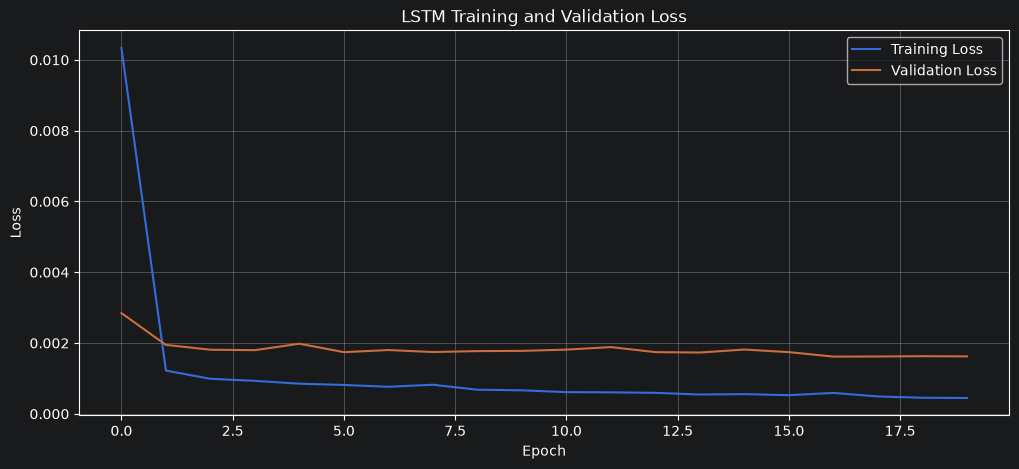

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Make Predictions

In [11]:
predictions_scaled = model.predict(
    X_test,
    verbose=0
)

print("Predictions shape:", predictions_scaled.shape)

Predictions shape: (251, 1)


Convert Predictions Back to Actual Prices

In [12]:
# Convert predicted values back to original stock prices
predictions = scaler.inverse_transform(
    predictions_scaled
)

# Convert actual test values back to original prices
actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Predictions:", predictions.shape)
print("Actual:", actual_prices.shape)

Predictions: (251, 1)
Actual: (251, 1)


Get Correct Prediction Dates

In [13]:
# Test dates start from the 80% training point
prediction_dates = stock_data.index[training_size:]

# Make sure lengths match
print("Dates:", len(prediction_dates))
print("Actual:", len(actual_prices))
print("Predictions:", len(predictions))

Dates: 251
Actual: 251
Predictions: 251


Calculate Evaluation Metrics

In [14]:
mae = mean_absolute_error(
    actual_prices,
    predictions
)

mse = mean_squared_error(
    actual_prices,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    actual_prices,
    predictions
)

print("================================")
print("MODEL PERFORMANCE")
print("================================")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MODEL PERFORMANCE
MAE  : 6.0575
MSE  : 61.0450
RMSE : 7.8131
R²   : 0.9087


Actual vs Predicted Using Matplotlib

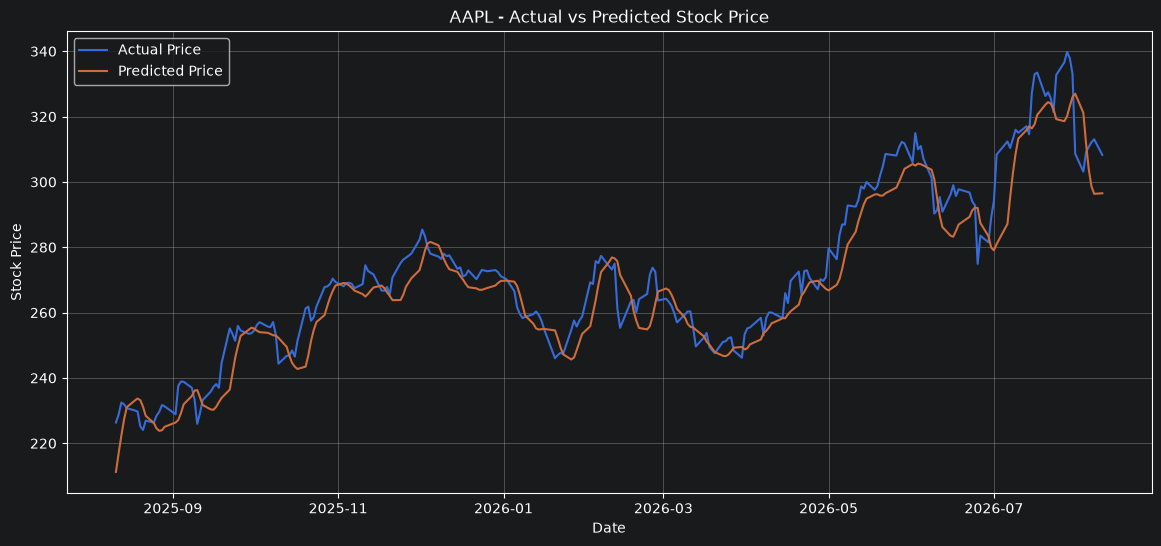

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    prediction_dates,
    actual_prices.flatten(),
    label="Actual Price"
)

plt.plot(
    prediction_dates,
    predictions.flatten(),
    label="Predicted Price"
)

plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title(f"{ticker} - Actual vs Predicted Stock Price")

plt.legend()
plt.grid(True)

plt.show()

Interactive Plotly Chart

In [16]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=prediction_dates,
        y=actual_prices.flatten(),
        mode="lines",
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=prediction_dates,
        y=predictions.flatten(),
        mode="lines",
        name="Predicted"
    )
)

fig.update_layout(
    title=f"{ticker} - Actual vs Predicted Stock Price",
    xaxis_title="Date",
    yaxis_title="Stock Price",
    hovermode="x unified"
)

fig.show()

Create Model Folder

In [17]:
model_folder = r"C:\Users\sruja\PycharmProjects\Stock-Price-Prediction\model"

os.makedirs(
    model_folder,
    exist_ok=True
)

print("Model folder:", model_folder)

Model folder: C:\Users\sruja\PycharmProjects\Stock-Price-Prediction\model


Save the LSTM Mode

In [18]:
model_path = os.path.join(
    model_folder,
    "stock_model.keras"
)

model.save(model_path)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
C:\Users\sruja\PycharmProjects\Stock-Price-Prediction\model\stock_model.keras


Save the scaler

In [19]:
scaler_path = os.path.join(
    model_folder,
    "scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print("Scaler saved successfully!")
print(scaler_path)

Scaler saved successfully!
C:\Users\sruja\PycharmProjects\Stock-Price-Prediction\model\scaler.pkl


Verify the both files

In [20]:
print(
    "Model exists:",
    os.path.exists(model_path)
)

print(
    "Scaler exists:",
    os.path.exists(scaler_path)
)

Model exists: True
Scaler exists: True


Test Loading the Saved Model

In [21]:
loaded_model = load_model(
    model_path
)

print("Model loaded successfully!")

Model loaded successfully!


Test Loading the Saved Scaler

In [22]:
loaded_scaler = joblib.load(
    scaler_path
)

print("Scaler loaded successfully!")

Scaler loaded successfully!
